## Multi-Trial LQG Control Model Analysis

This notebook runs multiple trials for each perturbation condition and computes average behavior metrics with standard errors.

**Note:** The LQG feedback controller alone (without feedforward learning) will show a small baseline endpoint error (~0.2-0.3 units) because it's designed for infinite-horizon regulation rather than finite-horizon reaching. This is expected behavior - in the full model, cerebellar feedforward adaptation would compensate for this systematic error.

# current question: why is trajectory undershooting the target?

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from model.lqg_control_model import LQGController, LQGParams, Perturbation
import model_utils

%matplotlib inline

### Initialize Controller and Parameters

In [2]:
# Initialize parameters and controller
params = LQGParams()
controller = LQGController(params)

# Create basis functions
Phi = controller.make_default_basis(n_basis=8, width=10.0)

# Initialize feedforward weights to zero (no learning)
ff_weights = controller.make_default_ff_weights(n_basis=8)

# Number of trials per condition
n_trials = 20

print(f"Target: {params.target}")
print(f"Number of trials per condition: {n_trials}")
print(f"Feedforward weights: all zeros (no learning)")
print(f"Expected baseline endpoint error: ~0.2-0.3 (due to finite-horizon effect)")

Target: [2. 2. 0. 0.]
Number of trials per condition: 20
Feedforward weights: all zeros (no learning)
Expected baseline endpoint error: ~0.2-0.3 (due to finite-horizon effect)


### Train Model to Learn Feedforward Weights

- The model needs to learn feedforward commands through cerebellar adaptation
to reach the target accurately. Without learning, the feedback controller alone cannot
compensate for the system dynamics (drag, noise) to achieve the target position.

### Define Perturbation Conditions

In [3]:
# Define all perturbation conditions
perturbations = {
    'Baseline': None,
    'Mossy Fiber': Perturbation(
        kind='mossy',
        onset_idx=45,
        duration=5,
        observer_bias=np.array([0.0, 0.0, 0.9, 0.5])
    ),
    'IntA→RN': Perturbation(
        kind='inta_rn',
        onset_idx=45,
        duration=5,
        pulse=np.array([-2.2, -1.0])
    ),
    'General IntA': Perturbation(
        kind='inta_general',
        onset_idx=45,
        duration=5,
        general_noise_std=0.5,
        pulse=np.array([-2.2, -1.0])
    )
}

print("Perturbation conditions defined:")
for name in perturbations.keys():
    print(f"  - {name}")

Perturbation conditions defined:
  - Baseline
  - Mossy Fiber
  - IntA→RN
  - General IntA


### Run Multiple Trials for Each Condition

In [4]:
# Storage for all results
all_results = {}
all_metrics = {}

# Run trials for each condition
for condition_name, perturbation in perturbations.items():
    print(f"Running {n_trials} trials for: {condition_name}")
    
    condition_results = []
    condition_metrics = []
    
    for trial in range(n_trials):
        # Simulate reach with unique random seed
        result = controller.simulate_reach(
            Phi=Phi,
            ff_weights=ff_weights,
            perturbation=perturbation,
            rng=np.random.default_rng(trial * 100 + hash(condition_name) % 100)
        )
        
        # Compute metrics
        metrics = model_utils.compute_behavior_metrics(result, params.target)
        
        condition_results.append(result)
        condition_metrics.append(metrics)
    
    all_results[condition_name] = condition_results
    all_metrics[condition_name] = condition_metrics
    print(f"  Completed {condition_name}")

Running 20 trials for: Baseline
  Completed Baseline
Running 20 trials for: Mossy Fiber
  Completed Mossy Fiber
Running 20 trials for: IntA→RN
  Completed IntA→RN
Running 20 trials for: General IntA
  Completed General IntA


### Compute Average Metrics and Standard Errors

In [5]:
# Compute mean and SEM for each condition
summary_stats = {}

for condition_name, metrics_list in all_metrics.items():
    # Convert list of dicts to dict of arrays
    metrics_arrays = {}
    for key in metrics_list[0].keys():
        metrics_arrays[key] = np.array([m[key] for m in metrics_list])
    
    # Compute mean and SEM
    mean_metrics = {}
    sem_metrics = {}
    for key, values in metrics_arrays.items():
        mean_metrics[key] = np.mean(values)
        sem_metrics[key] = np.std(values, ddof=1) / np.sqrt(len(values))
    
    summary_stats[condition_name] = {
        'mean': mean_metrics,
        'sem': sem_metrics,
        'raw': metrics_arrays
    }

print("Summary statistics computed for all conditions.")

Summary statistics computed for all conditions.


### Summary Table: Mean ± SEM

In [6]:
# Create summary table with mean ± SEM
summary_data = {}

for condition_name, stats in summary_stats.items():
    summary_data[condition_name] = {
        key: f"{stats['mean'][key]:.4f} ± {stats['sem'][key]:.4f}"
        for key in stats['mean'].keys()
    }

summary_df = pd.DataFrame(summary_data).T
print("\nSummary Stats (Mean ± SEM)")
display(summary_df)


Summary Stats (Mean ± SEM)


,endpoint_error,peak_outward_vel,min_outward_vel,rebound_magnitude,rebound_idx,peak_innovation,cost_J
Baseline,0.2907 ± 0.0150,2.8168 ± 0.0086,0.0000 ± 0.0000,2.8168 ± 0.0086,20.8000 ± 0.3449,0.1119 ± 0.0024,55291.7273 ± 335.9989
Mossy Fiber,0.2919 ± 0.0113,2.8063 ± 0.0093,0.0000 ± 0.0000,2.8063 ± 0.0093,20.0000 ± 0.4413,2.0530 ± 0.0053,55218.2484 ± 364.2915
IntA→RN,0.2891 ± 0.0119,2.8285 ± 0.0151,0.0000 ± 0.0000,2.8285 ± 0.0151,20.3000 ± 0.3635,0.1160 ± 0.0018,55736.9979 ± 407.4217
General IntA,0.3143 ± 0.0134,2.8012 ± 0.0092,0.0000 ± 0.0000,2.8012 ± 0.0092,20.1000 ± 0.2705,0.1147 ± 0.0020,55916.2248 ± 493.3196


### Plot: Endpoint Error Comparison

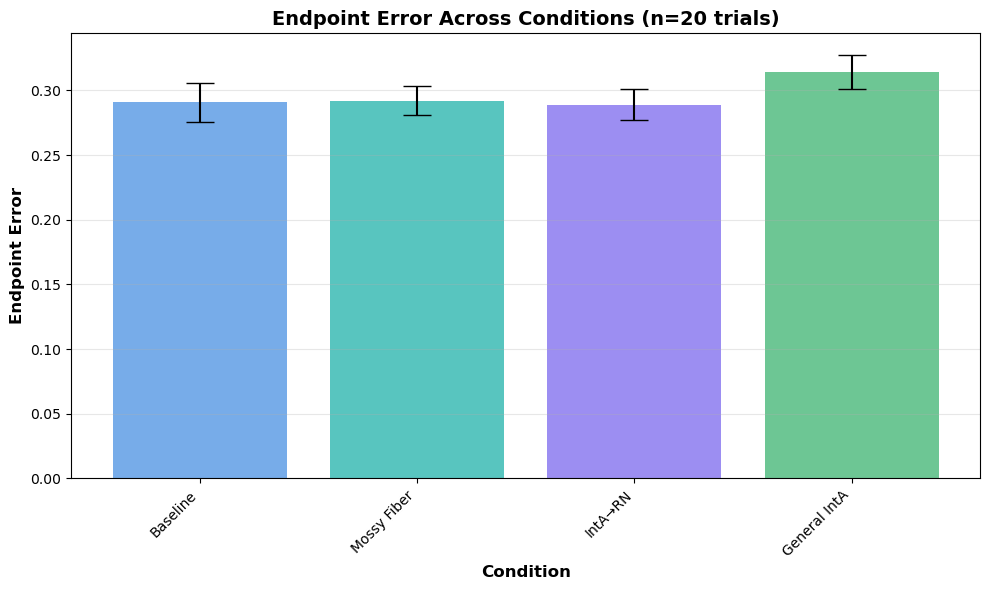

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Extract endpoint errors
conditions = list(summary_stats.keys())
means = [summary_stats[c]['mean']['endpoint_error'] for c in conditions]
sems = [summary_stats[c]['sem']['endpoint_error'] for c in conditions]

# Bar plot with error bars - cool colors
x_pos = np.arange(len(conditions))
bars = ax.bar(x_pos, means, yerr=sems, capsize=10, alpha=0.75, 
              color=['#4A90E2', '#20B2AA', '#7B68EE', '#3CB371'])

ax.set_xlabel('Condition', fontsize=12, fontweight='bold')
ax.set_ylabel('Endpoint Error', fontsize=12, fontweight='bold')
ax.set_title(f'Endpoint Error Across Conditions (n={n_trials} trials)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(conditions, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Plot: Cost Comparison

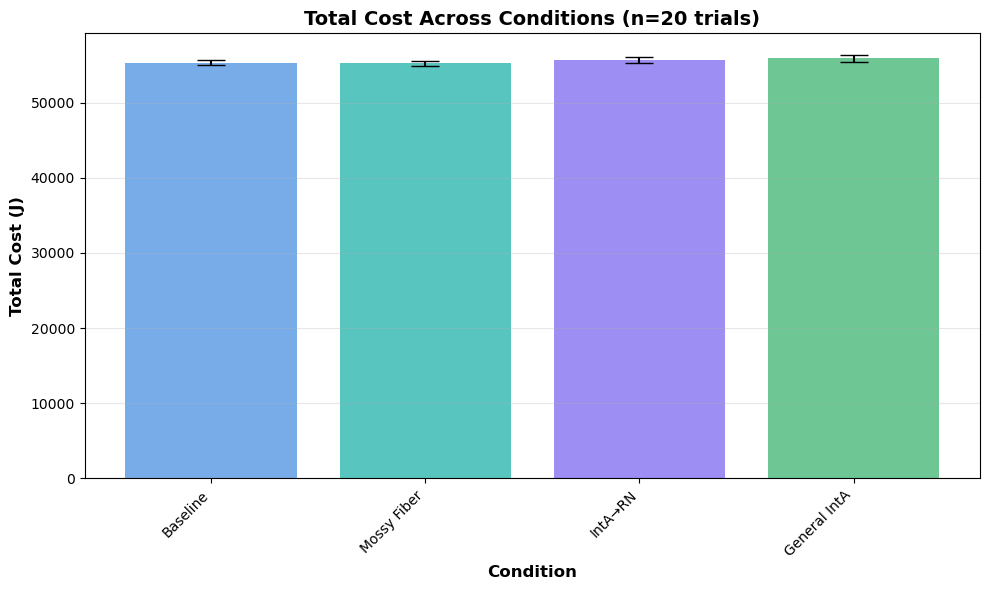

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Extract costs
means = [summary_stats[c]['mean']['cost_J'] for c in conditions]
sems = [summary_stats[c]['sem']['cost_J'] for c in conditions]

# Bar plot with error bars - cool colors
bars = ax.bar(x_pos, means, yerr=sems, capsize=10, alpha=0.75,
              color=['#4A90E2', '#20B2AA', '#7B68EE', '#3CB371'])

ax.set_xlabel('Condition', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Cost (J)', fontsize=12, fontweight='bold')
ax.set_title(f'Total Cost Across Conditions (n={n_trials} trials)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(conditions, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Plot: Peak Innovation (Prediction Error)

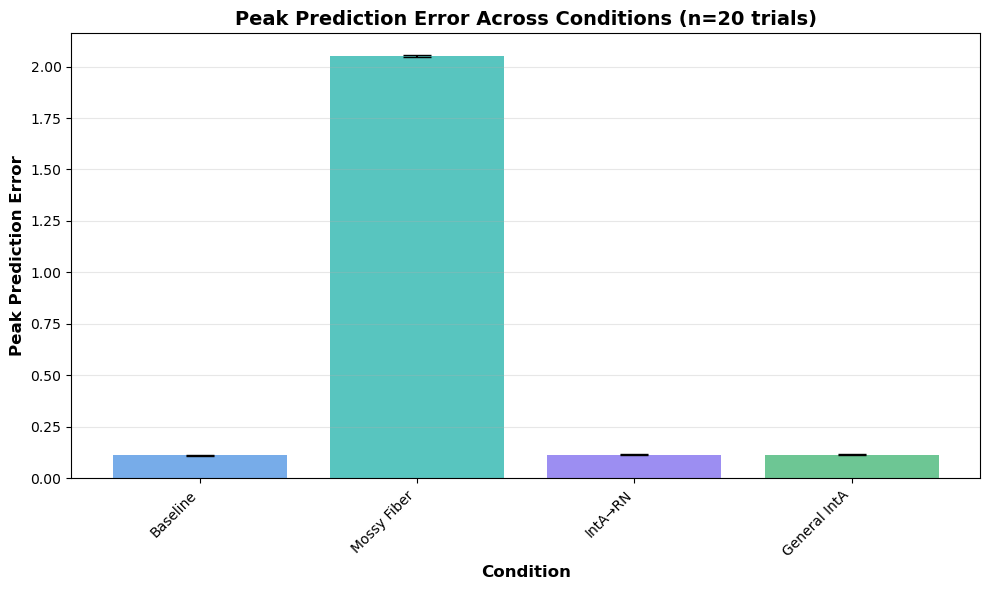

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Extract peak innovations
means = [summary_stats[c]['mean']['peak_innovation'] for c in conditions]
sems = [summary_stats[c]['sem']['peak_innovation'] for c in conditions]

# Bar plot with error bars - cool colors
bars = ax.bar(x_pos, means, yerr=sems, capsize=10, alpha=0.75,
              color=['#4A90E2', '#20B2AA', '#7B68EE', '#3CB371'])

ax.set_xlabel('Condition', fontsize=12, fontweight='bold')
ax.set_ylabel('Peak Prediction Error', fontsize=12, fontweight='bold')
ax.set_title(f'Peak Prediction Error Across Conditions (n={n_trials} trials)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(conditions, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Plot: All Metrics Comparison

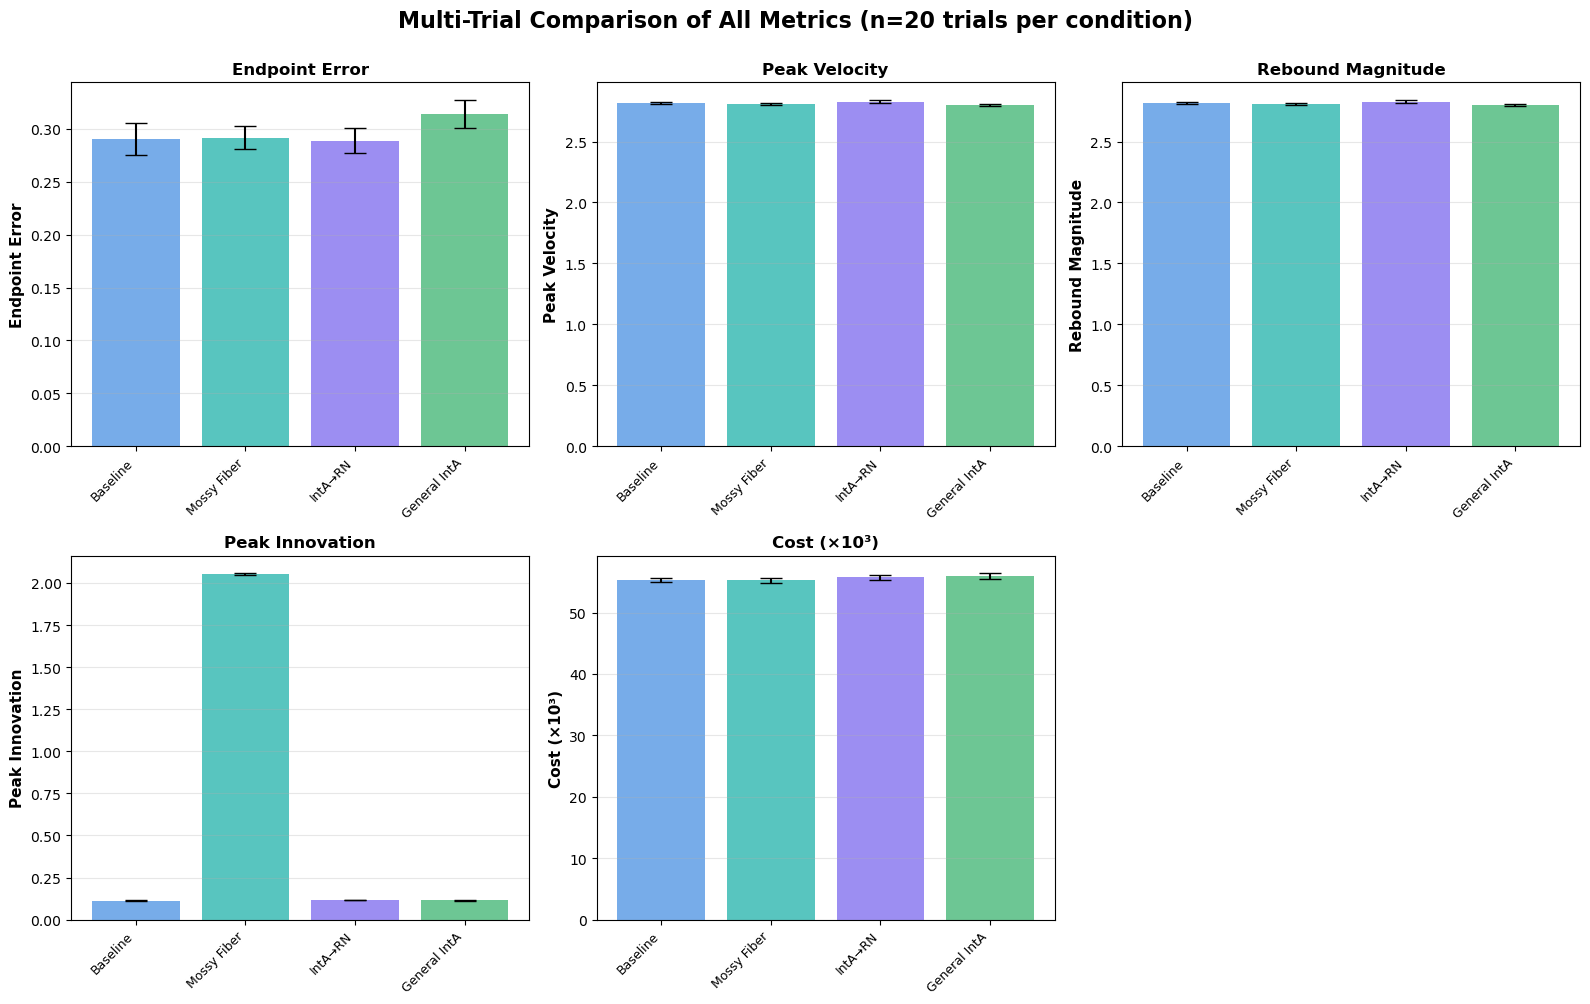

In [10]:
# Create a comprehensive comparison plot
metric_names = ['endpoint_error', 'peak_outward_vel', 'rebound_magnitude', 'peak_innovation', 'cost_J']
metric_labels = ['Endpoint Error', 'Peak Velocity', 'Rebound Magnitude', 'Peak Innovation', 'Cost (×10³)']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (metric, label) in enumerate(zip(metric_names, metric_labels)):
    ax = axes[idx]
    
    means = [summary_stats[c]['mean'][metric] for c in conditions]
    sems = [summary_stats[c]['sem'][metric] for c in conditions]
    
    # Scale cost for readability
    if metric == 'cost_J':
        means = [m / 1000 for m in means]
        sems = [s / 1000 for s in sems]
    
    bars = ax.bar(x_pos, means, yerr=sems, capsize=8, alpha=0.75,
                  color=['#4A90E2', '#20B2AA', '#7B68EE', '#3CB371'])
    
    ax.set_ylabel(label, fontsize=11, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(conditions, rotation=45, ha='right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_title(label, fontsize=12, fontweight='bold')

# Remove extra subplot
fig.delaxes(axes[5])

plt.suptitle(f'Multi-Trial Comparison of All Metrics (n={n_trials} trials per condition)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### Plot: Example Trajectories from Each Condition

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


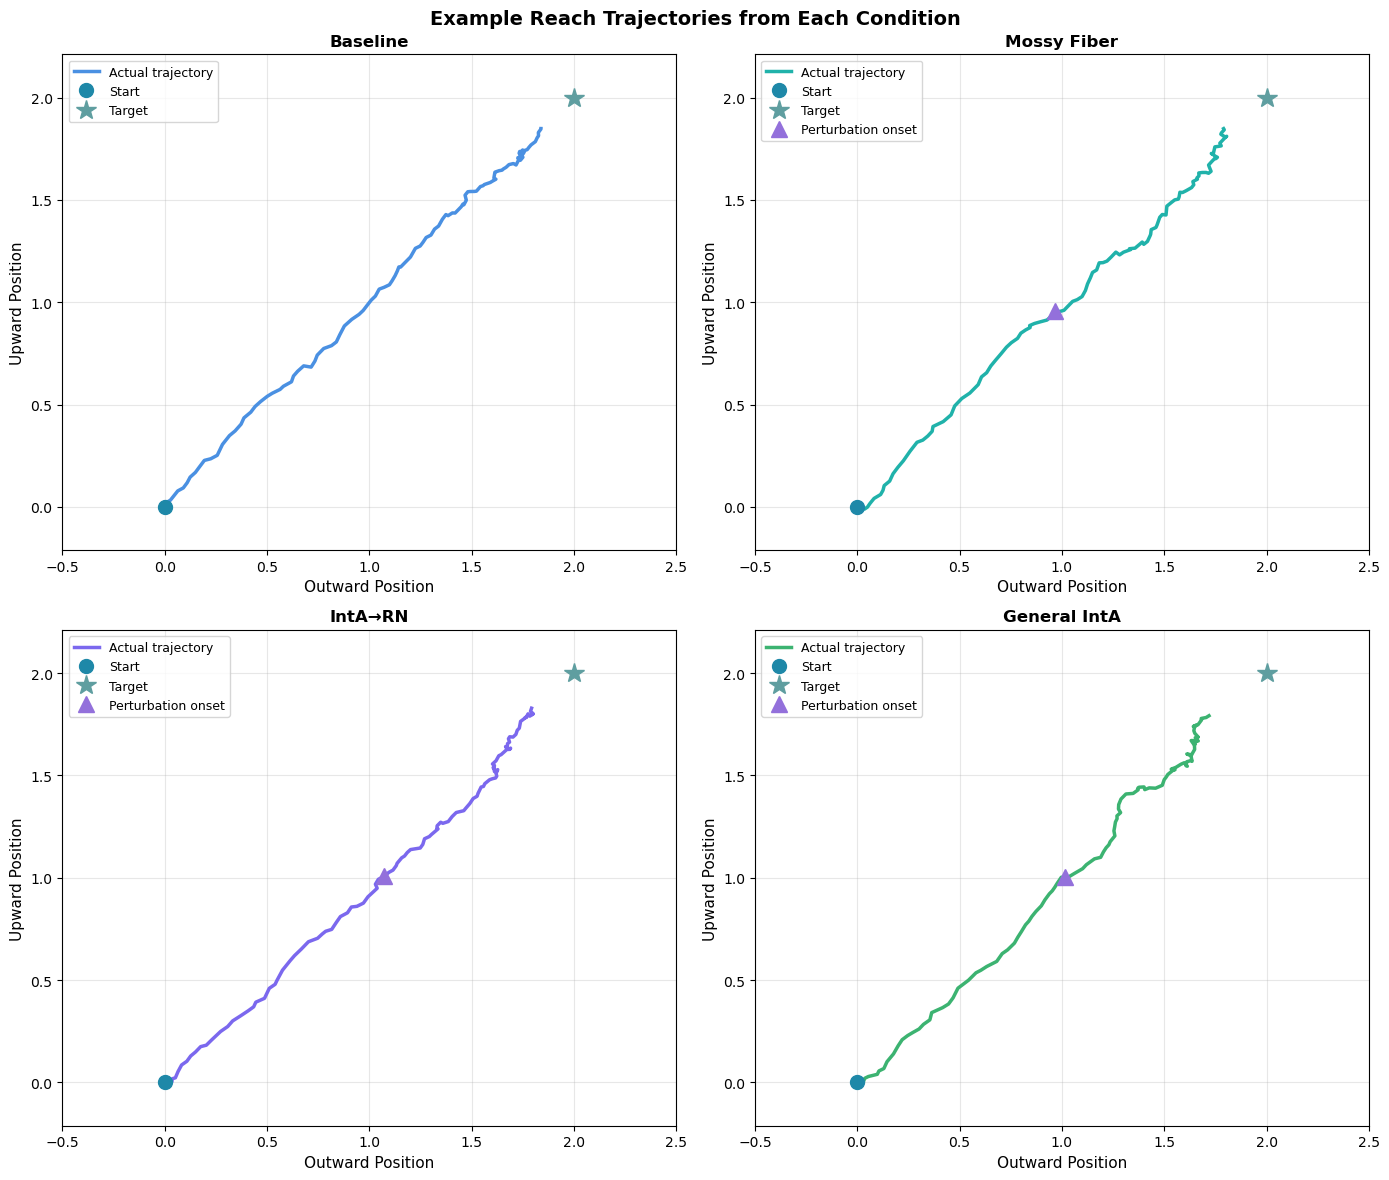

In [11]:
# Plot one example trajectory from each condition
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

colors = ['#4A90E2', '#20B2AA', '#7B68EE', '#3CB371']

for idx, (condition_name, color) in enumerate(zip(conditions, colors)):
    ax = axes[idx]
    
    # Get first trial result
    result = all_results[condition_name][0]
    
    # Plot trajectory
    ax.plot(result['x'][:, 0], result['x'][:, 1], 
            color=color, linewidth=2.5, label='Actual trajectory')
    ax.plot(0, 0, 'o', color='#1E88A8', markersize=10, label='Start')
    ax.plot(params.target[0], params.target[1], '*', color='#5F9EA0',
            markersize=15, label='Target')
    
    # Mark perturbation onset if applicable
    if perturbations[condition_name] is not None:
        pert = perturbations[condition_name]
        onset_pos = result['x'][pert.onset_idx]
        ax.plot(onset_pos[0], onset_pos[1], '^', color='#9370DB',
                markersize=12, label='Perturbation onset')
    
    ax.set_xlabel('Outward Position', fontsize=11)
    ax.set_ylabel('Upward Position', fontsize=11)
    ax.set_title(condition_name, fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    ax.set_xlim([-0.5, 2.5])
    ax.set_ylim([-0.5, 2.5])

plt.suptitle('Example Reach Trajectories from Each Condition', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Statistical Comparison: Export Data

### Summary

In [12]:
print("Summary")

# Find condition with highest/lowest metrics
endpoint_errors = {c: summary_stats[c]['mean']['endpoint_error'] for c in conditions}
costs = {c: summary_stats[c]['mean']['cost_J'] for c in conditions}
innovations = {c: summary_stats[c]['mean']['peak_innovation'] for c in conditions}

print(f"\nEndpoint Error:")
print(f"  Lowest:  {min(endpoint_errors, key=endpoint_errors.get)} = {min(endpoint_errors.values()):.4f}")
print(f"  Highest: {max(endpoint_errors, key=endpoint_errors.get)} = {max(endpoint_errors.values()):.4f}")

print(f"\nTotal Cost:")
print(f"  Lowest:  {min(costs, key=costs.get)} = {min(costs.values()):.2f}")
print(f"  Highest: {max(costs, key=costs.get)} = {max(costs.values()):.2f}")

print(f"\nPeak Prediction Error:")
print(f"  Lowest:  {min(innovations, key=innovations.get)} = {min(innovations.values()):.4f}")
print(f"  Highest: {max(innovations, key=innovations.get)} = {max(innovations.values()):.4f}")

Summary

Endpoint Error:
  Lowest:  IntA→RN = 0.2891
  Highest: General IntA = 0.3143

Total Cost:
  Lowest:  Mossy Fiber = 55218.25
  Highest: General IntA = 55916.22

Peak Prediction Error:
  Lowest:  Baseline = 0.1119
  Highest: Mossy Fiber = 2.0530
